In [230]:
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import csv
import re
import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import RegexpTokenizer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem import SnowballStemmer 
from collections import Counter
from collections import defaultdict
import random
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import time
from xgboost import XGBRanker
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
from torch import nn
from transformers import BertTokenizer
from transformers import BertModel
from tqdm import tqdm
from collections import OrderedDict

# Data Preprocessing

In [160]:
validation_data = pd.read_csv('validation_data.tsv', sep='\t',header=0,low_memory=False)
validation_data

,qid,pid,queries,passage,relevancy
0,1082792,1000084,what does the golgi apparatus do to the protei...,"Start studying Bonding, Carbs, Proteins, Lipid...",0.0
1,995825,1000492,where is the graphic card located in the cpu,"For example, a “PC Expansion Card” maybe the j...",0.0
2,995825,1000494,where is the graphic card located in the cpu,The Common Cards & Buses. The most common type...,0.0
3,1091246,1000522,property premises meaning,The occurrence of since tells us that the firs...,0.0
4,1047854,1000585,what is printing mechanism,Windows desktop applications Develop Desktop t...,0.0
...,...,...,...,...,...
1103034,176994,999706,dynamic link library meaning,Internet Public Library – The Internet Public ...,0.0
1103035,1089177,999765,united home life insurance phone number,Geico Customer Service Phone Number: 1-800-861...,0.0
1103036,42555,999824,average salary for primary care sports medicin...,The current average NBA salary of $6.2 million...,0.0
1103037,1044249,999824,what is the average salary of an nba player,The current average NBA salary of $6.2 million...,0.0


In [182]:
def preprocess(text, stopword=False, stemming=True):
    stop_words = set(stopwords.words('english')) 
    tokenizer = RegexpTokenizer(r'\s+', gaps=True)
    tokens = []
    stemmer = SnowballStemmer('english')
    
    for line in text:
        line = line.lower()
        # remove all punctuation marks
        punctuations =re.compile('[%s]' % re.escape(string.punctuation))
        line = punctuations.sub('', line)
        # Remove all characters except for letters (a-zA-Z) and spaces.
        line = re.sub(r'[^a-zA-Z\s]', u' ', line, flags=re.UNICODE)
        token_words = tokenizer.tokenize(line)

        # stop word removal
        if stopword:
            token_words = [word for word in token_words if word not in stop_words]
            
        # lemmatisation & stemming
        if stemming:
            token_words = [stemmer.stem(word) for word in token_words]
        
        tokens.append(token_words)
        
    return tokens

In [8]:
# 1103039 rows
processed_valid_query = preprocess(validation_data.queries, stopword = True, stemming = True)
processed_valid_passage = preprocess(validation_data.passage, stopword = True, stemming = True)

In [9]:
# 1148 qids and queries
valid_qid_query = dict(zip(validation_data.qid, processed_valid_query))

# 955211 pids and passage
valid_pid_passage = dict(zip(validation_data.pid, processed_valid_passage)) 

In [12]:
# np.save('valid_qid_query.npy',valid_qid_query)
# np.save('valid_pid_passage.npy',valid_pid_passage)
valid_qid_query = np.load('valid_qid_query.npy',allow_pickle=True).tolist()
valid_pid_passage = np.load('valid_pid_passage.npy',allow_pickle=True).tolist()

In [4]:
def inverse_index(data_dict):
    inverted_index = defaultdict(lambda: defaultdict(int))  # {word: {pid: frequency}}
    
    for pid, passage in data_dict.items():
        for word in passage:
            inverted_index[word][pid] += 1  # Record (pid, term frequency) for each word
    
    return dict(inverted_index)

In [84]:
# inverted_index = inverse_index(valid_pid_passage)
# np.save('inverted_index.npy',inverted_index)
inverted_index = np.load('inverted_index.npy',allow_pickle=True).tolist()

In [242]:
# 1103039 rows
val_qid_list = list(validation_data.qid)
val_pid_list = list(validation_data.pid)

In [164]:
def match_qid_pid(qid, qid_list, pid_list):
    
    indices = [i for i, qid_ in enumerate(qid_list) if qid_ == qid]
    match_pid = [pid_list[i] for i in indices]
    
    return indices, match_pid

In [241]:
def BM25(qid, pid_passage_dict, qid_query_dict, inverted_index, N, avdl, k1=1.2, k2=100, b=0.75, topk=100):

    query = qid_query_dict[qid]
    query_counter = Counter(query)
    query_tokens = query_counter.items()

    indices, match_pids = match_qid_pid(qid, val_qid_list, val_pid_list)
    score_list = {}

    for pid in match_pids:
        passage = pid_passage_dict[pid]
        dl = len(passage)
        K = k1 * ((1 - b) + b * dl / avdl)
        score = 0

        for token, qfi in query_tokens:
            if token in passage:
                fi = inverted_index[token][pid]
                ni = len(inverted_index[token])
            else:
                fi = 0
                ni = 0

            idf = np.log(((0.5) / (0.5)) / ((ni + 0.5) / (N - ni)))
            term_score = idf * (k1 + 1) * fi * (k2 + 1) * qfi / ((K + fi) * (k2 + qfi))
            score += term_score

        score_list[pid] = score

    top_score = dict(sorted(score_list.items(), key=lambda x: x[1], reverse=True)[:topk])
    return top_score

In [76]:
def BM25_model_topk(valid_pid_passage, valid_qid_query, inverted_index, N, avdl, k1=1.2, k2=100, b=0.75, topk=100):
    BM25_topk = {}
    for qid in valid_qid_query.keys():
        pid_score = BM25(qid, valid_pid_passage, valid_qid_query, inverted_index, N, avdl, k1=1.2, k2=100, b=0.75, topk=topk)
        BM25_topk[qid] = pid_score
    return BM25_topk

In [13]:
N = len(validation_data) # 1103039
L = 0
for pid, item in valid_pid_passage.items():
    L += len(item)
avdl = L / len(valid_pid_passage.keys()) # 32.209788203862814

In [96]:
BM25_top5 = BM25_model_topk(valid_pid_passage, valid_qid_query, inverted_index, N, avdl, k1=1.2, k2=100, b=0.75, topk=5)

In [97]:
BM25_top20 = BM25_model_topk(valid_pid_passage, valid_qid_query, inverted_index, N, avdl, k1=1.2, k2=100, b=0.75, topk=20)

In [98]:
BM25_top100 = BM25_model_topk(valid_pid_passage, valid_qid_query, inverted_index, N, avdl, k1=1.2, k2=100, b=0.75, topk=100)

# Task1: Evaluate Retrival Quality

In [5]:
def reformat_data_as_dict(data_set):

    relevant_dict = defaultdict(dict)
    irrelevant_dict = defaultdict(dict)
    
    for idx, (qid, pid, relevancy) in enumerate(zip(data_set.qid, data_set.pid, data_set.relevancy)):
        if relevancy > 0:
            relevant_dict[qid][pid] = idx
        else:
            irrelevant_dict[qid][pid] = idx
    
    return dict(relevant_dict), dict(irrelevant_dict)

In [169]:
# 1148 qids
valid_relevant_dict, valid_irrelevant_dict = reformat_data_as_dict(validation_data)

In [170]:
def MAP(model_output):
    AP = list()
    qid_list = list(model_output.keys())
    for qid in qid_list:
        ranked_pid = model_output[qid]
        relevant_pid = valid_relevant_dict[qid]
        
        if all(i not in ranked_pid.keys() for i in relevant_pid.keys()):
            metric = 0
            
        else:
            num_relevant = 0
            total = 0
            precision = 0
            
            for pid in ranked_pid.keys():
                total += 1 
                if pid in relevant_pid.keys():
                    num_relevant += 1
                    relevancy = validation_data.relevancy[relevant_pid[pid]]
                    precision += num_relevant / total * relevancy
                else:
                    precision += 0
        
            metric = precision / num_relevant
        AP.append(metric)

    return np.mean(AP)

In [99]:
BM25_MAP_5 = MAP(BM25_top5)  # 0.20987224157955867
BM25_MAP_20 = MAP(BM25_top20) # 0.2319928935132317
BM25_MAP_100 = MAP(BM25_top100) # 0.235431807020736

In [104]:
BM25_MAP_5

0.20987224157955867

In [109]:
BM25_MAP_20

0.2319928935132317

In [110]:
BM25_MAP_100

0.235431807020736

In [171]:
def NDCG(model_output):
    NDCG = list()
    qid_list = list(model_output.keys())
    for qid in qid_list:
        ranked_pid = model_output[qid]
        relevant_pid = valid_relevant_dict[qid]
        
        if all(i not in ranked_pid.keys() for i in relevant_pid.keys()):
            metric = 0
            
        else:
            DCG = 0
            ideal_dict = {}
            
            for pid in ranked_pid.keys():
                if pid in relevant_pid.keys():
                    relevancy = validation_data.relevancy[relevant_pid[pid]]
                    rank = list(ranked_pid).index(pid) + 1
                    DCG += (2**relevancy-1) / np.log2(rank + 1)
                    
                    idx = relevant_pid[pid]
                    ideal = {pid: validation_data.relevancy[idx]} 
                    ideal_dict = {**ideal_dict,**ideal} 
                    
                else:
                    DCG += 0                    
                 
            IDCG = 0 
            ideal_dict = sorted(ideal_dict.items(), key=lambda x: x[1], reverse = True)
            for i in range(len(ideal_dict)):
                relevancy = ideal_dict[i][1]
                rank = i+1
                IDCG += (2**relevancy - 1) / np.log2(rank + 1)
                
            metric = DCG / IDCG
            
        NDCG.append(metric)
    
    return np.mean(NDCG)

In [100]:
BM25_NDCG_5 = NDCG(BM25_top5) # 0.25235862225071254
BM25_NDCG_20 = NDCG(BM25_top20) # 0.0.31768002880186375
BM25_NDCG_100 = NDCG(BM25_top100) # 0.3549849590720915

In [101]:
BM25_NDCG_5

0.25235862225071254

In [102]:
BM25_NDCG_20

0.31768002880186375

In [103]:
BM25_NDCG_100

0.3549849590720915

# Task2: Logistic Regression (LR)

In [6]:
train_data = pd.read_csv('train_data.tsv', sep='\t', header=0, low_memory=False)
train_rel_dict, train_irrel_dict = reformat_data_as_dict(train_data)

# validation_data = pd.read_csv('validation_data.tsv', sep='\t',header=0,low_memory=False)
# validation_data

In [214]:
def down_negtive_sampling(data):
    
    candidate_idx = []
    for qid, rel in train_rel_dict.items():
        rel_idx = list(rel.values())

        irrel_idx = list(train_irrel_dict.get(qid, {}).values())
        if len(irrel_idx) > 30:
            irrel_idx = random.sample(irrel_idx, 30)

        candidate_idx.extend(rel_idx)
        candidate_idx.extend(irrel_idx)
        
    sub_data = data.iloc[candidate_idx].reset_index(drop=True)

    return sub_data

In [215]:
random.seed(62)
train_subdata = down_negtive_sampling(train_data)

In [216]:
train_subdata # 140931 rows

,qid,pid,queries,passage,relevancy
0,709560,1050990,what is all in basic metabolic panel,Basic Metabolic Panel. The basic metabolic pan...,1.0
1,709560,516191,what is all in basic metabolic panel,A Basic Metabolic Panel (BMP) is a common scre...,0.0
2,709560,1001700,what is all in basic metabolic panel,Requirements: The Arthritis Basic Panel requir...,0.0
3,709560,6443213,what is all in basic metabolic panel,"2. Before the Basal Metabolic Rate is taken, t...",0.0
4,709560,6033088,what is all in basic metabolic panel,"Metabolic profiles often require fasting, acco...",0.0
...,...,...,...,...,...
140926,969974,7147435,where did the the trail of tears end,"Trail of the Week: Hoh River Trail, Olympic Na...",0.0
140927,969974,4700747,where did the the trail of tears end,Palmer (1989) classified TFCC tears into 2 cla...,0.0
140928,969974,5129138,where did the the trail of tears end,The trail returns to the junction of the trail...,0.0
140929,969974,1009967,where did the the trail of tears end,The Act of Union created a unified political b...,0.0


In [121]:
# train_subdata.to_csv('train_subdata.csv', index=False)
train_subdata = pd.read_csv('train_subdata.csv')

In [16]:
subtrain_relevant_dict, subtrain_irrelevant_dict = reformat_data_as_dict(train_subdata)

In [217]:
# 140931 rows
processed_subtrain_query = preprocess(train_subdata.queries, stopword = True, stemming = True)
processed_subtrain_passage = preprocess(train_subdata.passage, stopword = True, stemming = True)
# # 1103039 rows
# processed_valid_query = preprocess(validation_data.queries, stopword = True, stemming = True)
# processed_valid_passage = preprocess(validation_data.passage, stopword = True, stemming = True)

In [218]:
# 4590 qids and queries
subtrain_qid_query = dict(zip(train_subdata.qid, processed_subtrain_query))

# 136899 pids and passage
subtrain_pid_passage = dict(zip(train_subdata.pid, processed_subtrain_passage))

In [ ]:
np.save('subtrain_qid_query.npy', subtrain_qid_query)
np.save('subtrain_pid_passage.npy', subtrain_pid_passage)

In [124]:
subtrain_qid_query = np.load('subtrain_qid_query.npy', allow_pickle=True).tolist()
subtrain_pid_passage = np.load('subtrain_pid_passage.npy', allow_pickle=True).tolist()

In [219]:
W2Vc_subtrain_query = Word2Vec(processed_subtrain_query, vector_size=100, sg=1, window=5, min_count=1, negative=5, workers=4)
W2Vc_subtrain_passage = Word2Vec(processed_subtrain_passage, vector_size=100, sg=1, window=5, min_count=1, negative=5, workers=4)

In [92]:
W2Vc_valid_query = Word2Vec(processed_valid_query, vector_size=100, sg=1, window=5, min_count=1, negative=5, workers=4)
W2Vc_valid_passage = Word2Vec(processed_valid_passage, vector_size=100, sg=1, window=5, min_count=1, negative=5, workers=4)

In [220]:
def average_embedding(data, eb_model):

    EB_dict = {}
    
    for key, text in data.items():
        N = len(text) 
        
        if N != 0:
            text_wv = sum(eb_model.wv[text]) / N 

            EB_dict[key] = text_wv
        
    return EB_dict

In [221]:
subtrain_qid_Qembedding = average_embedding(subtrain_qid_query, W2Vc_subtrain_query) # 4589
subtrain_pid_Pembedding = average_embedding(subtrain_pid_passage, W2Vc_subtrain_passage) # 136899

In [24]:
np.save('subtrain_qid_Qembedding.npy', subtrain_qid_Qembedding)
np.save('subtrain_pid_Pembedding.npy', subtrain_pid_Pembedding)

In [24]:
subtrain_qid_Qembedding = np.load('subtrain_qid_Qembedding.npy', allow_pickle=True).tolist()
subtrain_pid_Pembedding = np.load('subtrain_pid_Pembedding.npy', allow_pickle=True).tolist()

In [95]:
valid_qid_Qembedding = average_embedding(valid_qid_query, W2Vc_valid_query) # 1148
valid_pid_Pembedding = average_embedding(valid_pid_passage, W2Vc_valid_passage) # 955

In [96]:
np.save('valid_qid_Qembedding.npy', valid_qid_Qembedding)
np.save('valid_pid_Pembedding.npy', valid_pid_Pembedding)

In [157]:
valid_qid_Qembedding = np.load('valid_qid_Qembedding.npy', allow_pickle=True).tolist()
valid_pid_Pembedding = np.load('valid_pid_Pembedding.npy', allow_pickle=True).tolist()

In [113]:
def pd_dataframe(data, query_embedding, passage_embedding):
    """
        A function construct new dataFrame with format <qid, pid, query vector, passage vector, relevancy>
        Inputs:
          data: original dataset 
          embedding_query: embeddings for queries in data
          embedding_passage: embeddings for passages in data
          relevant_dict: relevancy in data
        Outputs:
           new_dataFrame: same as original dataset with query and passage columns changing to embedding vectors
    """
    new_data = {
    "qid": [],
    "pid": [],
    "q_vector": [],
    'p_vector': [],
    'relevancy': []
    }
    N = len(data)
    for idx in range(N):
        qid = data.qid[idx]
        pid = data.pid[idx]
        if qid in query_embedding.keys() and pid in passage_embedding.keys():
            query_vec = query_embedding[qid]
            passage_vec = passage_embedding[pid]
            rel = data.relevancy[idx]
            new_data["qid"].append(qid)
            new_data["pid"].append(pid)
            new_data["q_vector"].append(query_vec)
            new_data["p_vector"].append(passage_vec)
            new_data["relevancy"].append(rel)
            
    new_data = pd.DataFrame(new_data)
    
    return new_data

In [136]:
LR_subtrain_df = pd_dataframe(train_subdata, subtrain_qid_Qembedding, subtrain_pid_Pembedding)
LR_subtrain_df # 140922 rows

,qid,pid,q_vector,p_vector,relevancy
0,709560,1050990,"[0.110375464, 0.051445115, -0.13778089, -0.037...","[0.060846455, -0.43764308, -0.32153603, -0.054...",1.0
1,709560,516191,"[0.110375464, 0.051445115, -0.13778089, -0.037...","[0.037378754, -0.41147208, -0.38043773, 0.0155...",0.0
2,709560,1001700,"[0.110375464, 0.051445115, -0.13778089, -0.037...","[0.15412202, -0.31194317, -0.015667632, 0.0811...",0.0
3,709560,6443213,"[0.110375464, 0.051445115, -0.13778089, -0.037...","[0.026601331, -0.34497595, 0.025246825, -0.098...",0.0
4,709560,6033088,"[0.110375464, 0.051445115, -0.13778089, -0.037...","[0.18456747, -0.4025415, -0.07353598, -0.04304...",0.0
...,...,...,...,...,...
140917,969974,7147435,"[-0.42531076, -0.13589907, -0.53899264, -0.119...","[-0.23669589, -0.21248706, 0.18026231, 0.41600...",0.0
140918,969974,4700747,"[-0.42531076, -0.13589907, -0.53899264, -0.119...","[0.089154206, -0.2676601, -0.10345661, 0.28559...",0.0
140919,969974,5129138,"[-0.42531076, -0.13589907, -0.53899264, -0.119...","[-0.25906238, -0.29177168, 0.09411902, 0.35335...",0.0
140920,969974,1009967,"[-0.42531076, -0.13589907, -0.53899264, -0.119...","[-0.24871507, -0.32480654, 0.14171314, 0.28089...",0.0


In [137]:
LR_subtrain_df.insert(2,'intercept',1)
LR_subtrain_array = LR_subtrain_df.values # convert dateFrame to matrix
LR_subtrain_array[:1]

array([[709560, 1050990, 1,
        array([ 0.11037546,  0.05144512, -0.13778089, -0.03795556, -0.4198309 ,
                0.41839376, -0.3921273 ,  0.00445455,  0.13858257,  0.01660346,
               -0.58384806,  0.28869534,  0.39909267, -0.8487733 ,  0.20487578,
               -0.4614434 ,  0.05343787, -0.38026777,  0.08592264,  0.04191774,
               -0.64375   ,  0.2857232 ,  0.16385897,  0.14125168,  0.32867292,
               -0.21474808,  0.00739735,  0.47034928,  0.04078622, -0.1809246 ,
                0.34339896, -0.09005829,  0.2733533 , -0.2334219 ,  0.06630575,
                0.17197426, -0.09336483,  0.29874703, -0.07491178, -0.3246692 ,
               -0.12419   ,  0.15454893, -0.2799683 , -0.05205985, -0.23167409,
               -0.02089464, -0.3443761 , -0.15469855, -0.12133139,  0.05588306,
                0.00148222, -0.15906598, -0.3336948 ,  0.26601073,  0.27827382,
               -0.87567466,  0.07964016,  0.310722  , -0.57149816,  0.26847696,
            

In [138]:
def fetch_Xy(data):
    X = data[:, 2:5]
    X_subtrain = np.array([np.hstack(x) for x in X])
    y_subtrain = data[:, 5].reshape(-1, 1)

    return X_subtrain, y_subtrain

In [139]:
LR_X_subtrain, LR_y_subtrain = fetch_Xy(LR_subtrain_array)

In [140]:
LR_X_subtrain
LR_X_subtrain.shape

(140922, 201)

In [141]:
LR_y_subtrain
LR_y_subtrain.shape

(140922, 1)

In [142]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def model_func(w, X):
    return sigmoid(np.dot(X, w)) # calculate all y_i = w^T * x_i，shape (n, 1)

def loss_func(w, X, y):
    # X: input feature matrix, shape (n, d)
    # y: label array, shape (n,)
    # w: weight vector, shape (d, 1)
    
    y_predicts = model_func(w, X) # shape (n, 1)
    
    loss = - (y * np.log(y_predicts) + (1 - y) * np.log(1 - y_predicts))  # shape (n, 1)
    mean_loss = np.mean(loss)
    return mean_loss

def gradient(w, X, y):
    # X: input feature matrix, shape (n, d)
    # y: label array, shape (n,)
    # w: weight vector, shape (d, 1)
    
    y_predicts = model_func(w, X) # shape (n, 1)

    error = y - y_predicts  # calculation error，shape (n, 1)
    grad_w = -np.dot(X.T, error) / len(y)  # gradient, X.T is (d, n)，error is (n, 1)，thus grad_w is (d, 1)
    return np.array(grad_w, dtype=np.float64)


In [153]:
def mini_batch_sgd(data, batch_size, max_iter, lr, tol):
    X, y = fetch_Xy(data)
    m = len(X)
    np.random.seed(82)
    w = np.random.randn(201, 1) * 0.01
    losses = []
    iteration = 0
    mini_batch = 0
    stop_condition = True
    
    while (iteration < max_iter and stop_condition == True):
        # Randomly select a mini-batch
        X_batch = X[mini_batch: mini_batch + batch_size]
        y_batch = y[mini_batch: mini_batch + batch_size]
        mini_batch += batch_size
        if mini_batch >= m:
            mini_batch = 0
            indices = np.arange(X.shape[0])
            np.random.seed(int(time.time()))
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]
        
        # Calculating the gradient
        dw = gradient(w, X_batch, y_batch)
        
        # Update w
        w -= lr * dw
        iteration += 1

        loss = loss_func(w, X, y)
        losses.append(loss)
        
        if iteration == 1 or iteration % 1000 == 0:
            print(f"Iteration {iteration}, Loss: {loss}")

        if np.linalg.norm(dw) < tol:
            stop_condition == False

    return w, losses

In [154]:
def search_parameter(data, batch_size, max_iter, tol, learning_rates = []):
    # Dictionary to store the loss values corresponding to each learning rate
    losses_dict = {}
    
    # For each learning rate, train the model and record the loss
    for lr in learning_rates:
        print(f"learning_rate: {lr}")
        _, losses = mini_batch_sgd(data, batch_size, max_iter, lr, tol)
        losses_dict[lr] = losses
        
    # Plotting loss curves
    plt.figure(figsize=(10, 6))
    for lr, losses in losses_dict.items():
        plt.plot(range(1, len(losses) + 1), losses, label=f'lr={lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch for Different Learning Rates')
    plt.legend()
    plt.savefig("LR_epoch3000.pdf", format='pdf')
    plt.show()

learning_rate: 0.1
Iteration 1, Loss: 0.5174605917770558
Iteration 1000, Loss: 0.14912040804602741
Iteration 2000, Loss: 0.14836637910370942
Iteration 3000, Loss: 0.14810341848471928
learning_rate: 0.05
Iteration 1, Loss: 0.6009284842032556
Iteration 1000, Loss: 0.14978628444665282
Iteration 2000, Loss: 0.14881898411553526
Iteration 3000, Loss: 0.14841945097033676
learning_rate: 0.01
Iteration 1, Loss: 0.6762781003942874
Iteration 1000, Loss: 0.15159729669727545
Iteration 2000, Loss: 0.15084605019854075
Iteration 3000, Loss: 0.15023238263170852
learning_rate: 0.005
Iteration 1, Loss: 0.6862400273448807
Iteration 1000, Loss: 0.15288707462574266
Iteration 2000, Loss: 0.15150871703983712
Iteration 3000, Loss: 0.15103139472361515
learning_rate: 0.001
Iteration 1, Loss: 0.6942967155230368
Iteration 1000, Loss: 0.19297299045493607
Iteration 2000, Loss: 0.16299365907269187
Iteration 3000, Loss: 0.15584982490518293


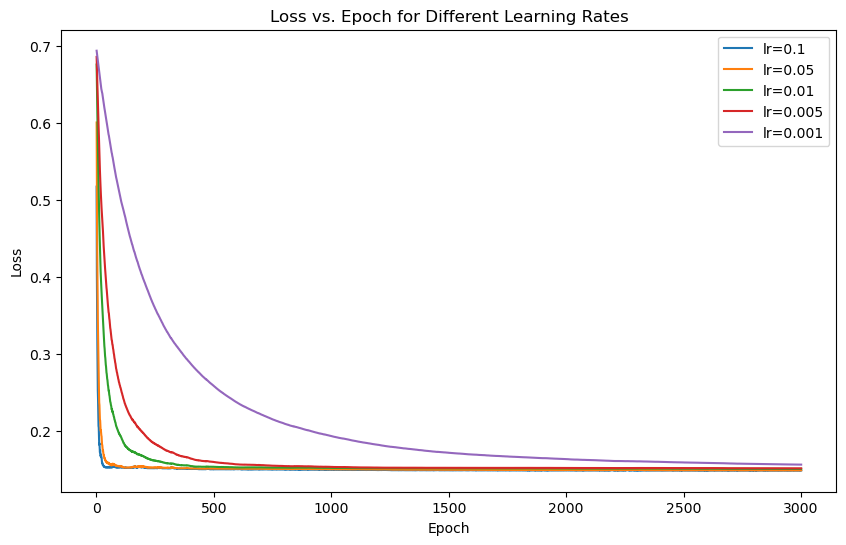

In [155]:
lr = [0.1, 0.05, 0.01, 0.005, 0.001]
search_parameter(LR_subtrain_array, batch_size=10, max_iter=3000, tol=0.01, learning_rates = lr)

In [156]:
w, _= mini_batch_sgd(LR_subtrain_array, batch_size=10, max_iter=5000, lr = 0.05, tol=0.001)

Iteration 1, Loss: 0.6009284842032556
Iteration 1000, Loss: 0.14978628444665282
Iteration 2000, Loss: 0.14881898411553526
Iteration 3000, Loss: 0.14841945097033676
Iteration 4000, Loss: 0.14810437072070118
Iteration 5000, Loss: 0.1479595976714653


In [196]:
def LR_model_score(qid, qid_list, pid_list, qid_query_embedding, pid_passage_embedding, w, topk=100):

    indices, match_pids = match_qid_pid(qid, qid_list, pid_list) # coresponding pid
    query_embedding = qid_query_embedding[qid]
    score_list = []
    for pid in match_pids:
        passage_embedding = pid_passage_embedding[pid]
        concate_embedding = np.concatenate((np.array([1]), query_embedding, passage_embedding), axis=0)
        score = model_func(w, concate_embedding)[0]
        score_list.append(score)
        
    pid_score = {pid: float(score) for pid, score in zip(match_pids, score_list)}
    top_score = dict(sorted(pid_score.items(), key=lambda x: x[1], reverse=True)[:topk])
    
    return top_score

In [232]:
def LR_model_topk(qid_list, pid_list, qid_query_embedding, pid_passage_embedding, w, topk=100):
    qid_topk = {}
    for qid in list(OrderedDict.fromkeys(qid_list)):
        top_score = LR_model_score(qid, qid_list, pid_list, qid_query_embedding, pid_passage_embedding, w, topk=100)
        if len(top_score) == 100:
            qid_topk = {**qid_topk, **{qid: top_score}}
        
    return qid_topk

In [ ]:
val_qid_list = list(validation_data.qid)
val_pid_list = list(validation_data.pid)

In [ ]:
LR_top100 = LR_model_topk(val_qid_list, val_pid_list, valid_qid_Qembedding, valid_pid_Pembedding, w, topk=100)

In [172]:
LR_MAP = MAP(LR_top100)

In [174]:
LR_MAP # 0.00363877946317027

0.0036909640636945545

In [173]:
LR_NDCG = NDCG(LR_top100)

In [175]:
LR_NDCG # 0.017526628619544612

0.017261492156512327

In [178]:
test_data = pd.read_csv('candidate_passages_top1000.tsv', sep='\t', header=None, names=['qid', 'pid', 'queries', 'passage'], low_memory=False)
test_data

,qid,pid,queries,passage
0,494835,7130104,"sensibilities, definition",This is the definition of RNA along with examp...
1,1128373,7130104,iur definition,This is the definition of RNA along with examp...
2,131843,7130104,definition of a sigmet,This is the definition of RNA along with examp...
3,20455,7130335,ar glasses definition,Best Answer: The AR designation comes from the...
4,719381,7130335,what is ar balance,Best Answer: The AR designation comes from the...
...,...,...,...,...
189872,1056204,79980,who was the first steam boat operator,Other operators with special formats accept mo...
189873,1132213,7998257,how long to hold bow in yoga,You may be surprised that to learn that yoga t...
189874,324211,7998651,how much money a united airline get as a capta...,Find cheap airline tickets & deals on flights ...
189875,1116341,7998709,closed ended mortgage definition,"What is a wrap-around mortgage, and who is it ..."


In [204]:
processed_test_query = preprocess(test_data.queries, stopword = True, stemming = True)
processed_test_passage = preprocess(test_data.passage, stopword = True, stemming = True)

In [ ]:
W2Vc_test_query = Word2Vec(processed_test_query, vector_size=100, sg=1, window=5, min_count=1, negative=5, workers=4)
W2Vc_test_passage = Word2Vec(processed_test_passage, vector_size=100, sg=1, window=5, min_count=1, negative=5, workers=4)

In [185]:
test_qid_query = dict(zip(test_data.qid, processed_test_query))
test_pid_passage = dict(zip(test_data.pid, processed_test_passage))

In [186]:
test_qid_Qembedding = average_embedding(test_qid_query, W2Vc_test_query)
test_pid_Pembedding = average_embedding(test_pid_passage, W2Vc_test_passage)

In [198]:
test_qid_list = list(test_data.qid)
test_pid_list = list(test_data.pid)

In [233]:
LR_test_top100 = LR_model_topk(test_qid_list, test_pid_list, test_qid_Qembedding, test_pid_Pembedding, w, topk=100)

In [200]:
def write_nested_dict_to_file(result, filename, algoname):
    with open(filename, 'w') as f:
        for qid, pid_score_dict in result.items():
            # Add rankings by score and format the output
            for rank, (pid, score) in enumerate(pid_score_dict.items(), start=1):
                f.write(f"{qid} A2 {pid} {rank} {score} {algoname}\n")

In [234]:
write_nested_dict_to_file(LR_test_top100, 'LR.txt', 'LR')

# Task3: LambdaMART (LM)

In [205]:
LM_subtrain_df = pd_dataframe(train_subdata, subtrain_qid_Qembedding, subtrain_pid_Pembedding)
LM_subtrain_array = LM_subtrain_df.values
X = LM_subtrain_array[:, 2:4]
LM_X_subtrain = np.array([np.hstack(x) for x in X])
LM_y_subtrain = LM_subtrain_array[:, 4]

In [206]:
def set_group(qid_list):
    qid_size = list()
    for qid in set(qid_list):
        size = qid_list.count(qid)
        qid_size.append(size)
        
    return qid_size
    
subtrain_group = set_group(list(LM_subtrain_df.qid))

In [47]:
learning_rate = [0.1, 0.05, 0.01]
max_depth = [6, 8, 10]
n_estimators = [100, 300]
LM_models = []

for lr in learning_rate:
    for depth in max_depth:
        for n in n_estimators:
            LM_models.append(XGBRanker(
                objective='rank:ndcg',
                learning_rate = lr,
                max_depth=depth,
                n_estimators=n
            ))

for model in LM_models:
    model.fit(LM_X_subtrain, LM_y_subtrain, group=subtrain_group)

In [208]:
def LM_model_score(qid, qid_list, pid_list, qid_query_embedding, pid_passage_embedding, model, topk=100):
    indices, match_pids = match_qid_pid(qid, qid_list, pid_list) # coresponding pid
    query_embedding = qid_query_embedding[qid]
    X = list()
    for pid in match_pids:
        passage_embedding = pid_passage_embedding[pid]
        concate_embedding = np.concatenate((query_embedding, passage_embedding), axis=0)
        X.append(concate_embedding)
    X = np.array(X)
    score_list = model.predict(X)
    
    pid_score = {pid: float(score) for pid, score in zip(match_pids, score_list)}
    top_score = dict(sorted(pid_score.items(), key=lambda x: x[1], reverse=True)[:topk])
    
    return top_score

In [235]:
def LM_model_topk(qid_list, pid_list, qid_query_embedding, pid_passage_embedding, model, topk=100):
    qid_topk = {}
    for qid in list(OrderedDict.fromkeys(qid_list)):
        top_score = LM_model_score(qid, qid_list, pid_list, qid_query_embedding, pid_passage_embedding, model, topk=100)
        if len(top_score) == 100:
            qid_topk = {**qid_topk, **{qid: top_score}}
        
    return qid_topk

In [ ]:
val_qid_list = list(validation_data.qid)
val_pid_list = list(validation_data.pid)

In [51]:
model_result = []
for i, model in enumerate(LM_models):
    LM_top100 = LM_model_topk(val_qid_list, val_pid_list, valid_qid_Qembedding, valid_pid_Pembedding, model, topk=100)
    model_result.append(LM_top100)
    LM_MAP = MAP(LM_top100)
    LM_NDCG = NDCG(LM_top100)
    print(f"model {i} MAP: {LM_MAP} NDCG: {LM_NDCG}")

model 0 MAP: 0.006324939699848888 NDCG: 0.026441598136130236
model 1 MAP: 0.00795206911567653 NDCG: 0.02588233080600957
model 2 MAP: 0.010616022976653367 NDCG: 0.03141728295706517
model 3 MAP: 0.008188353307050159 NDCG: 0.029099130086526565
model 4 MAP: 0.005740966523737707 NDCG: 0.023091142372036393
model 5 MAP: 0.007229685843619805 NDCG: 0.024969092448532224
model 6 MAP: 0.003599633920525831 NDCG: 0.02027348439810886
model 7 MAP: 0.0066097409500726215 NDCG: 0.025071703969017138
model 8 MAP: 0.007748687259212188 NDCG: 0.025497548549055393
model 9 MAP: 0.0054289727075260506 NDCG: 0.024858817450727908
model 10 MAP: 0.005206341729229144 NDCG: 0.02351670459084268
model 11 MAP: 0.00523881164983507 NDCG: 0.02470015112176591
model 12 MAP: 0.006234486532085866 NDCG: 0.02751209408239593
model 13 MAP: 0.006438085024387438 NDCG: 0.025799431839576142
model 14 MAP: 0.005816604446058719 NDCG: 0.025983998343216
model 15 MAP: 0.006119020641931709 NDCG: 0.02480760681431193
model 16 MAP: 0.005896841191

In [53]:
Best_LM_MAP = MAP(model_result[2])
Best_LM_MAP

0.010616022976653367

In [54]:
Best_LM_NDCG = NDCG(model_result[2])
Best_LM_NDCG

0.03141728295706517

In [ ]:
test_qid_list = list(test_data.qid)
test_pid_list = list(test_data.pid)

In [222]:
best_model = XGBRanker(
                objective='rank:ndcg',
                learning_rate=0.1,
                max_depth=8,
                n_estimators=100
            )
best_model.fit(LM_X_subtrain, LM_y_subtrain, group=subtrain_group)

In [236]:
LM_test_top100 = LM_model_topk(test_qid_list, test_pid_list, test_qid_Qembedding, test_pid_Pembedding, best_model, topk=100)

In [237]:
write_nested_dict_to_file(LM_test_top100, 'LM.txt', 'LM')

# Task4: Neural Network Model (NN)

In [9]:
# random.seed(62)
# train_subdata = down_negtive_sampling(train_data)
# train_subdata.to_csv('train_subdata.csv', index=False)
train_subdata = pd.read_csv('train_subdata.csv')
train_subdata

,qid,pid,queries,passage,relevancy
0,709560,1050990,what is all in basic metabolic panel,Basic Metabolic Panel. The basic metabolic pan...,1.0
1,709560,516191,what is all in basic metabolic panel,A Basic Metabolic Panel (BMP) is a common scre...,0.0
2,709560,1001700,what is all in basic metabolic panel,Requirements: The Arthritis Basic Panel requir...,0.0
3,709560,6443213,what is all in basic metabolic panel,"2. Before the Basal Metabolic Rate is taken, t...",0.0
4,709560,6033088,what is all in basic metabolic panel,"Metabolic profiles often require fasting, acco...",0.0
...,...,...,...,...,...
140926,969974,7147435,where did the the trail of tears end,"Trail of the Week: Hoh River Trail, Olympic Na...",0.0
140927,969974,4700747,where did the the trail of tears end,Palmer (1989) classified TFCC tears into 2 cla...,0.0
140928,969974,5129138,where did the the trail of tears end,The trail returns to the junction of the trail...,0.0
140929,969974,1009967,where did the the trail of tears end,The Act of Union created a unified political b...,0.0


In [10]:
def BERT_data(data):
    data_dict = {}
    qid_list = data.qid
    pid_list = data.pid
    query_list = data.queries
    passage_list = data.passage
    relevancy_list = data.relevancy
    
    for idx, qid in enumerate(qid_list):
        relevancy = relevancy_list[idx]
        pid = pid_list[idx]
        query = query_list[idx]
        passage = passage_list[idx]
        if qid in data_dict:
            if relevancy > 0:
                data_dict[qid]["query"] = query
                data_dict[qid]["pos_passages"].append(passage)
            else:
                data_dict[qid]["query"] = query
                data_dict[qid]["neg_passages"].append(passage)
        else:
            data_dict[qid] = {}
            if relevancy > 0:
                data_dict[qid]["query"] = query
                data_dict[qid]["pos_passages"] = [passage]
                data_dict[qid]["neg_passages"] = []
            else:
                data_dict[qid]["query"] = query
                data_dict[qid]["pos_passages"] = []
                data_dict[qid]["neg_passages"] = [passage]   
    
    return list(data_dict.values())

In [11]:
BERT_subtrain = BERT_data(train_subdata)

In [20]:
# BERT_subtrain[1]

In [31]:
len(BERT_subtrain[1]["neg_passages"])

30

In [9]:
# Checks if "neg_passages" is in the current item and if it is an empty list.
for index, item in enumerate(BERT_subtrain):
    if "neg_passages" in item and isinstance(item["neg_passages"], list):
        if len(item["neg_passages"]) == 0:
            print(f"Item at index {index} has an empty 'neg_passages' list.")
    else:
        print(f"Item at index {index} does not have 'neg_passages' or it is not a list.")

In [13]:
BERT_subtrain = [item for item in BERT_subtrain if not (len(item["neg_passages"]) == 0)]

In [30]:
def find_max_avg_length(data):
    max_length = 0
    max_text = ""
    max_type = ""
    overall_total_words = 0
    overall_combination_count = 0
    
    for item in data:
        query = item["query"]

        local_total_words = 0
        local_combination_count = 0
        
        for pos in item["pos_passages"]:
            combined_text = query + " " + pos
            combined_length = len(combined_text.split())

            local_total_words += combined_length
            local_combination_count += 1
            
            if combined_length > max_length:
                max_length = combined_length
                max_text = combined_text
                max_type = "pos"
    
        for neg in item["neg_passages"]:
            combined_text = query + " " + neg
            combined_length = len(combined_text.split())

            local_total_words += combined_length
            local_combination_count += 1
            
            if combined_length > max_length:
                max_length = combined_length
                max_text = combined_text
                max_type = "neg"
                
        overall_total_words += local_total_words
        overall_combination_count += local_combination_count
    
    print(f"Max length combination: {max_type} -> {max_length} words")
    print(f"Text: {max_text}")
    print("-" * 50)
    
    if overall_combination_count > 0:
        overall_avg = overall_total_words / overall_combination_count
        print(f"\n🔍 Overall Average Length of All Query-Passage Combinations: {overall_avg:.2f} words")

In [31]:
find_max_length(BERT_subtrain)

Max length combination: neg -> 240 words
Text: what does it mean when you dream about babies If you dream of a heron, it can mean that you soon will meet a stable or rich partner. It can also symbolize success and self-reliance. To see a bird's nest in your dream signifies comfort, safety, and protection. The dream may also symbolize new opportunities.To see an owl in a dream is symbolic of wisdom and virtue. To dream of a parakeet means that an idea lacks originality and energy and may fail.It can also mean that someone else is taking credit for your ideas. If you dream of a pelican, you might be pregnant. The bird is symbolic of motherhood, birth, and nurturing.If you dream of a penguin, it means that whatever problem is bothering you is not as serious as you think. To dream of a phoenix can mean that your past may come back to haunt you. To dream of a quail is an omen of good fortune.To shoot, kill, cook or eat a quail means that you will become very rich soon. Dreaming of a raven i

In [45]:
class ReRankDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        query = item["query"]
        pos = random.choice(item["pos_passages"])
        neg = random.choice(item["neg_passages"])

        pos_enc = self.tokenizer(query, pos, truncation="only_second", padding="max_length", max_length=self.max_length, return_tensors="pt")
        neg_enc = self.tokenizer(query, neg, truncation="only_second", padding="max_length", max_length=self.max_length, return_tensors="pt")

        return {
            "pos_input_ids": pos_enc["input_ids"].squeeze(0),
            "pos_attention_mask": pos_enc["attention_mask"].squeeze(0),
            "pos_token_type_ids": pos_enc["token_type_ids"].squeeze(0),
            "neg_input_ids": neg_enc["input_ids"].squeeze(0),
            "neg_attention_mask": neg_enc["attention_mask"].squeeze(0),
            "neg_token_type_ids": neg_enc["token_type_ids"].squeeze(0),
        }

In [227]:
class PassageReRanker(nn.Module):
    def __init__(self, pretrained_model='bert-base-uncased'):
        super().__init__()
        self.bert = BertModel.from_pretrained(pretrained_model)
        self.scorer = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask, token_type_ids):
        output = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask,
                           token_type_ids=token_type_ids)
        cls = output.pooler_output  # [CLS]
        score = self.scorer(cls)
        return score.squeeze(-1)

In [17]:
torch.cuda.empty_cache()

In [14]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 437102 KiB | 681105 KiB |  32536 GiB |  32536 GiB |
|       from large pool | 436608 KiB | 680445 KiB |  31559 GiB |  31558 GiB |
|       from small pool |    494 KiB |   5468 KiB |    977 GiB |    977 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 437102 KiB | 681105 KiB |  32536 GiB |  32536 GiB |
|       from large pool | 436608 KiB | 680445 KiB |  31559 GiB |

In [48]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
dataset = ReRankDataset(BERT_subtrain, tokenizer)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

model = PassageReRanker()
model.train()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.MarginRankingLoss(margin=1.0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def BERT_training(model, dataloader, optimizer, loss_fn):
    for epoch in range(5):  # epoch
        total_loss = 0
        for batch in tqdm(dataloader):
            pos_ids = batch['pos_input_ids'].to(device)
            pos_mask = batch['pos_attention_mask'].to(device)
            pos_type = batch['pos_token_type_ids'].to(device)
    
            neg_ids = batch['neg_input_ids'].to(device)
            neg_mask = batch['neg_attention_mask'].to(device)
            neg_type = batch['neg_token_type_ids'].to(device)
    
            optimizer.zero_grad()
            pos_scores = model(pos_ids, pos_mask, pos_type)
            neg_scores = model(neg_ids, neg_mask, neg_type)
    
            # The goal is: positive sample score > negative sample score
            target = torch.ones_like(pos_scores)
            loss = loss_fn(pos_scores, neg_scores, target)
    
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
            
            # Cleaning up useless variables
            del pos_ids, pos_mask, pos_type, neg_ids, neg_mask, neg_type, pos_scores, neg_scores
            torch.cuda.empty_cache()  # try to clear the cache
            
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

100%|██████████████████████████████████████████████████████████████████████████████| 4589/4589 [08:21<00:00,  9.15it/s]


Epoch 1 Loss: 734.5607


100%|██████████████████████████████████████████████████████████████████████████████| 4589/4589 [08:31<00:00,  8.97it/s]


Epoch 2 Loss: 435.7803


100%|██████████████████████████████████████████████████████████████████████████████| 4589/4589 [08:30<00:00,  8.99it/s]


Epoch 3 Loss: 432.2409


100%|██████████████████████████████████████████████████████████████████████████████| 4589/4589 [08:20<00:00,  9.17it/s]


Epoch 4 Loss: 367.0668


100%|██████████████████████████████████████████████████████████████████████████████| 4589/4589 [08:27<00:00,  9.04it/s]

Epoch 5 Loss: 374.9516


In [ ]:
BERT_training(model, dataloader, optimizer, loss_fn)

In [67]:
torch.save(model.state_dict(), "bert_ranker.pt")

In [247]:
def BERT_rank_passages(model, tokenizer, qid, qid_list, pid_list, batch_size=100, device="cuda", topk=100):
    
    indices, match_pids = match_qid_pid(qid, qid_list, pid_list) # coresponding pid
    passages = validation_data.loc[indices, "passage"].tolist()
    query = validation_data.loc[indices[0], "queries"]
    
    model.eval()
    inputs = tokenizer(
        [query] * len(passages),  # Multiple copies query
        passages,
        truncation="only_second",
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

    score_list = []
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]
    token_type_ids = inputs["token_type_ids"]
    total = input_ids.size(0)
    
    for i in range(0, total, batch_size):
        batch = {
            "input_ids": input_ids[i : i + batch_size].to(device),
            "attention_mask": attention_mask[i : i + batch_size].to(device),
            "token_type_ids": token_type_ids[i : i + batch_size].to(device)
        }
        with torch.no_grad():
            batch_scores = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch["token_type_ids"],
            )
        score_list = score_list + batch_scores.cpu().tolist()
        torch.cuda.empty_cache()
    
    pid_score = {pid: float(score) for pid, score in zip(match_pids, score_list)}
    top_score = dict(sorted(pid_score.items(), key=lambda x: x[1], reverse=True)[:topk])
    
    return top_score

In [248]:
def BERT_model_topk(qid_list, pid_list, model, tokenizer, batch_size=100, device="cuda", topk=100):
    qid_topk = {}
    for qid in tqdm(list(OrderedDict.fromkeys(qid_list))):
        top_score = BERT_rank_passages(model, tokenizer, qid, qid_list, pid_list, batch_size=100, device="cuda", topk=100)
        
        if len(top_score) == 100:
            qid_topk = {**qid_topk, **{qid: top_score}}

    return qid_topk

In [228]:
model = PassageReRanker()
model.load_state_dict(torch.load("bert_ranker.pt", map_location='cuda'))
model.to('cuda')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
val_qid_list = list(validation_data.qid)
val_pid_list = list(validation_data.pid)

In [41]:
BERT_top100 = BERT_model_topk(val_qid_list, val_pid_list, model, tokenizer, batch_size=1000, device="cuda", topk=100)

100%|████████████████████████████████████████████████████████████████████████████| 1148/1148 [2:09:01<00:00,  6.74s/it]


In [48]:
BERT_MAP = MAP(BERT_top100)

In [49]:
BERT_MAP

0.3268921030990304

In [50]:
BERT_NDCG = NDCG(BERT_top100)

In [51]:
BERT_NDCG

0.45272066871192274

In [249]:
test_qid_list = list(test_data.qid)
test_pid_list = list(test_data.pid)

In [250]:
BERT_test_top100 = BERT_model_topk(test_qid_list, test_pid_list, model, tokenizer, batch_size=1000, device="cuda", topk=100)

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [23:35<00:00,  7.08s/it]


In [251]:
write_nested_dict_to_file(BERT_test_top100, 'NN.txt', 'NN')